<a href="https://colab.research.google.com/github/sarangraje/Data-Science-R/blob/main/R-data-science/google-colab-r.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Colab R

- Google is now supporting a Colab notebook with the R kernel
- We can run R codes directly on Colab
- R Colab Notebook Link: [R Google Colab](https://colab.fan/r)
    - Colab with R kernel
    - With base-R installed
    - Run R codes immediately
    - No need to setup
    - Save a copy in your Drive


## Demonstration

This notebook uses the R kernel.


In [39]:
library(ggplot2)
library(dplyr)

df <- read.csv("/content/heart_failure_clinical_records_dataset.csv")
head(df)


Attaching package: ‘ggplot2’


The following object is masked from ‘package:randomForest’:

    margin



Attaching package: ‘dplyr’


The following object is masked from ‘package:randomForest’:

    combine


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,75,0,582,0,20,1,265000,1.9,130,1,0,4,1
2,55,0,7861,0,38,0,263358,1.1,136,1,0,6,1
3,65,0,146,0,20,0,162000,1.3,129,1,1,7,1
4,50,1,111,0,20,0,210000,1.9,137,1,0,7,1
5,65,1,160,1,20,0,327000,2.7,116,0,0,8,1
6,90,1,47,0,40,1,204000,2.1,132,1,1,8,1


In [40]:
dim(df)

[1] 299  13

In [41]:
str(df)

'data.frame':	299 obs. of  13 variables:
 $ age                     : num  75 55 65 50 65 90 75 60 65 80 ...
 $ anaemia                 : int  0 0 0 1 1 1 1 1 0 1 ...
 $ creatinine_phosphokinase: int  582 7861 146 111 160 47 246 315 157 123 ...
 $ diabetes                : int  0 0 0 0 1 0 0 1 0 0 ...
 $ ejection_fraction       : int  20 38 20 20 20 40 15 60 65 35 ...
 $ high_blood_pressure     : int  1 0 0 0 0 1 0 0 0 1 ...
 $ platelets               : num  265000 263358 162000 210000 327000 ...
 $ serum_creatinine        : num  1.9 1.1 1.3 1.9 2.7 2.1 1.2 1.1 1.5 9.4 ...
 $ serum_sodium            : int  130 136 129 137 116 132 137 131 138 133 ...
 $ sex                     : int  1 1 1 1 0 1 1 1 0 1 ...
 $ smoking                 : int  0 0 1 0 0 1 0 1 0 1 ...
 $ time                    : int  4 6 7 7 8 8 10 10 10 10 ...
 $ DEATH_EVENT             : int  1 1 1 1 1 1 1 1 1 1 ...


In [42]:
cols <- c("anaemia", "diabetes", "high_blood_pressure", "sex", "smoking", "DEATH_EVENT")

df[, cols] <- lapply(df[, cols], as.factor)

In [43]:
str(df)

'data.frame':	299 obs. of  13 variables:
 $ age                     : num  75 55 65 50 65 90 75 60 65 80 ...
 $ anaemia                 : Factor w/ 2 levels "0","1": 1 1 1 2 2 2 2 2 1 2 ...
 $ creatinine_phosphokinase: int  582 7861 146 111 160 47 246 315 157 123 ...
 $ diabetes                : Factor w/ 2 levels "0","1": 1 1 1 1 2 1 1 2 1 1 ...
 $ ejection_fraction       : int  20 38 20 20 20 40 15 60 65 35 ...
 $ high_blood_pressure     : Factor w/ 2 levels "0","1": 2 1 1 1 1 2 1 1 1 2 ...
 $ platelets               : num  265000 263358 162000 210000 327000 ...
 $ serum_creatinine        : num  1.9 1.1 1.3 1.9 2.7 2.1 1.2 1.1 1.5 9.4 ...
 $ serum_sodium            : int  130 136 129 137 116 132 137 131 138 133 ...
 $ sex                     : Factor w/ 2 levels "0","1": 2 2 2 2 1 2 2 2 1 2 ...
 $ smoking                 : Factor w/ 2 levels "0","1": 1 1 2 1 1 2 1 2 1 2 ...
 $ time                    : int  4 6 7 7 8 8 10 10 10 10 ...
 $ DEATH_EVENT             : Factor w/ 2 levels "

In [44]:
model_glm <- glm(DEATH_EVENT ~ ., data = df, family = binomial(link = "logit"))
summary(model_glm)


Call:
glm(formula = DEATH_EVENT ~ ., family = binomial(link = "logit"), 
    data = df)

Coefficients:
                           Estimate Std. Error z value Pr(>|z|)    
(Intercept)               1.018e+01  5.657e+00   1.801 0.071774 .  
age                       4.742e-02  1.580e-02   3.001 0.002690 ** 
anaemia1                 -7.470e-03  3.605e-01  -0.021 0.983467    
creatinine_phosphokinase  2.222e-04  1.779e-04   1.249 0.211684    
diabetes1                 1.451e-01  3.512e-01   0.413 0.679380    
ejection_fraction        -7.666e-02  1.633e-02  -4.695 2.67e-06 ***
high_blood_pressure1     -1.027e-01  3.587e-01  -0.286 0.774688    
platelets                -1.200e-06  1.889e-06  -0.635 0.525404    
serum_creatinine          6.661e-01  1.815e-01   3.670 0.000242 ***
serum_sodium             -6.698e-02  3.974e-02  -1.686 0.091855 .  
sex1                     -5.337e-01  4.139e-01  -1.289 0.197299    
smoking1                 -1.349e-02  4.126e-01  -0.033 0.973915    
time        

Call:
rpart(formula = DEATH_EVENT ~ age + serum_creatinine + ejection_fraction, 
    data = df, method = "class")
  n= 299 

          CP nsplit rel error  xerror       xstd
1 0.22916667      0 1.0000000 1.00000 0.08409628
2 0.08333333      1 0.7708333 0.87500 0.08095656
3 0.06250000      2 0.6875000 0.90625 0.08181270
4 0.01562500      3 0.6250000 0.81250 0.07909274
5 0.01000000      5 0.5937500 0.75000 0.07701447

Variable importance
 serum_creatinine ejection_fraction               age 
               46                32                22 

Node number 1: 299 observations,    complexity param=0.2291667
  predicted class=0  expected loss=0.3210702  P(node) =1
    class counts:   203    96
   probabilities: 0.679 0.321 
  left son=2 (251 obs) right son=3 (48 obs)
  Primary splits:
      serum_creatinine  < 1.815 to the left,  improve=19.04558, (0 missing)
      ejection_fraction < 27.5  to the right, improve=15.33700, (0 missing)
      age               < 71    to the left,  improve=

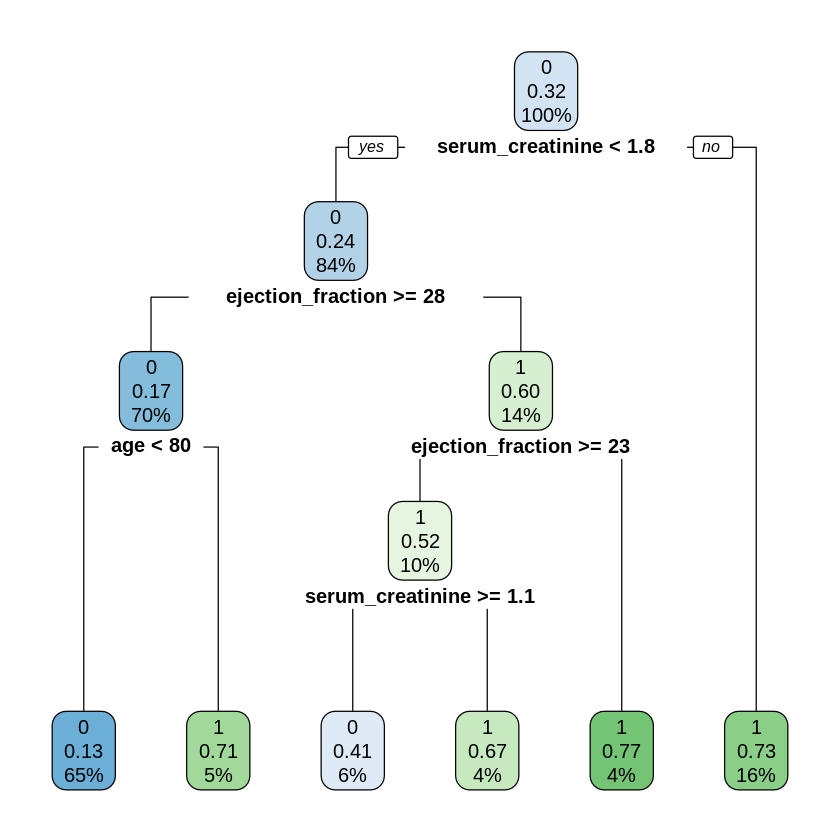

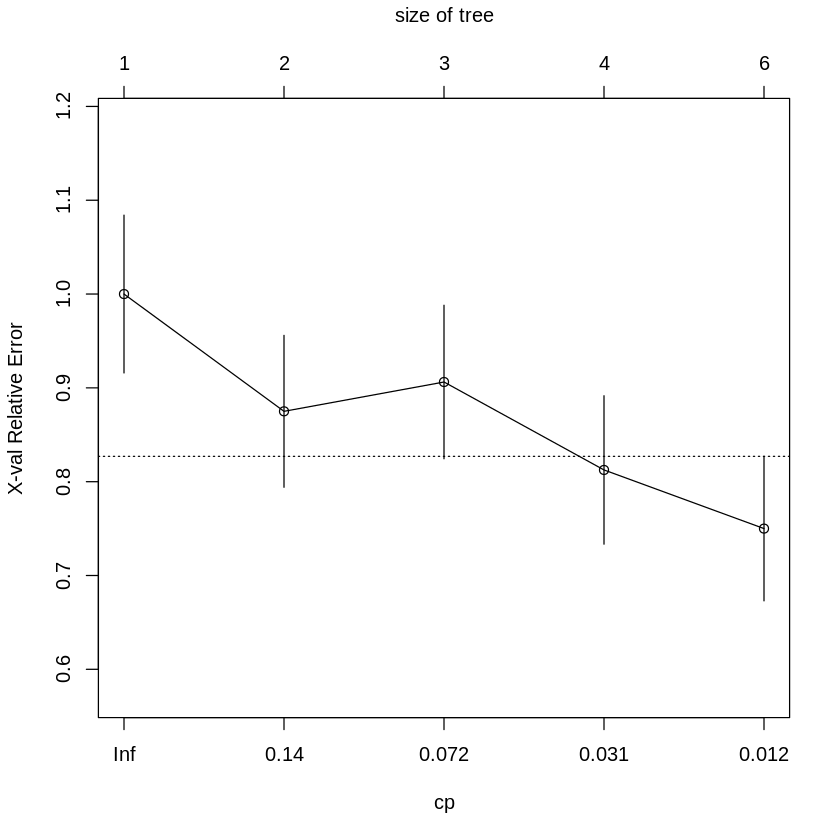

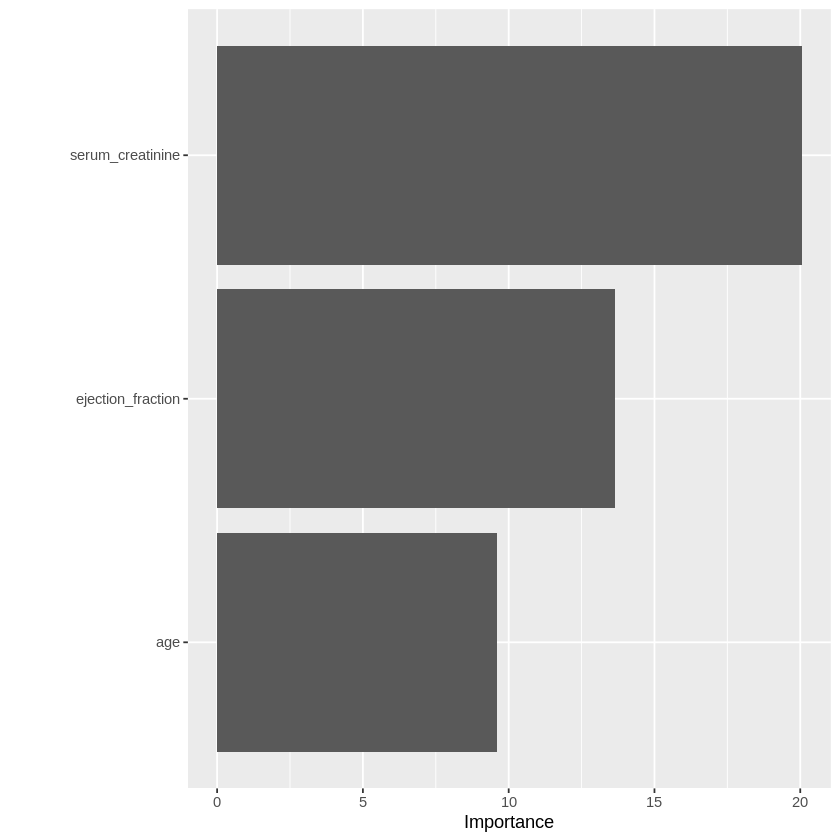

In [45]:

# install.packages("rpart.plot", quiet = TRUE)
# install.packages("vip", quiet = TRUE)

library(rpart.plot)
library("rpart")
library(vip)

model_tr <- rpart(DEATH_EVENT ~ age + serum_creatinine + ejection_fraction, data = df, method = "class")
summary(model_tr)

rpart.plot(model_tr)
plotcp(model_tr)
vip(model_tr)


                Length Class  Mode     
call              4    -none- call     
type              1    -none- character
predicted       299    factor numeric  
err.rate        750    -none- numeric  
confusion         6    -none- numeric  
votes           598    matrix numeric  
oob.times       299    -none- numeric  
classes           2    -none- character
importance        3    -none- numeric  
importanceSD      0    -none- NULL     
localImportance   0    -none- NULL     
proximity         0    -none- NULL     
ntree             1    -none- numeric  
mtry              1    -none- numeric  
forest           14    -none- list     
y               299    factor numeric  
test              0    -none- NULL     
inbag             0    -none- NULL     
terms             3    terms  call     

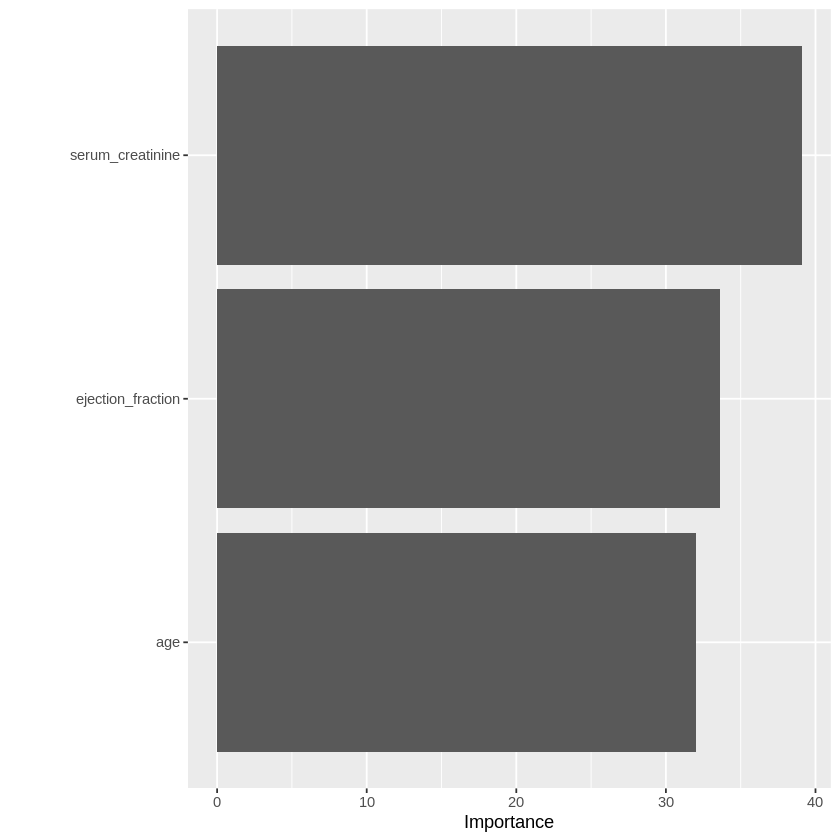

In [46]:
# install.packages("randomForest", quiet = TRUE)
library("randomForest")

model_rf <- randomForest(DEATH_EVENT ~ age + serum_creatinine + ejection_fraction, data = df, ntree = 250)
summary(model_rf)
vip(model_rf)